# Explore MODIS PCA Coefficients

In [31]:
# imports
from importlib import reload
import numpy as np
import os

import pandas

from matplotlib import pyplot as plt

from remote_sensing.plotting import utils as rs_putils

import info_defs

# Load up

## PCA

In [2]:
d = np.load('pca/pca_latents_MODIS_SST_2km.npz')
d.keys()

KeysView(NpzFile 'pca/pca_latents_MODIS_SST_2km.npz' with keys: Y, M, mean, explained_variance)

In [5]:
d['M'].shape, d['Y'].shape

((256, 256), (200000, 256))

## MODIS table

In [7]:
mdict = info_defs.grab_paths('MODIS_SST')
mdict

{'path': '/home/xavier/Projects/Oceanography/data/SST/MODIS_L2/Info',
 'preproc_file': '/home/xavier/Projects/Oceanography/data/SST/MODIS_L2/Info/PreProc/train_MODIS_2021_128x128.h5',
 'latents_file': '/home/xavier/Projects/Oceanography/data/SST/MODIS_L2/Info/latents/MODIS_2021/SimCLR_resnet50_lr_0.05_decay_0.0001_bsz_64_temp_0.07_trial_5_cosine_warm/train_MODIS_2021_128x128_latents.h5',
 'model_file': None,
 'opts_file': 'opts_nenya_modis.json',
 'pca_file': 'pca/pca_latents_MODIS_SST.npz'}

In [11]:
modis = pandas.read_parquet(os.path.join(mdict['path'], 'Tables', 'train_MODIS_2021_128x128.parquet'))
modis.head()

,filename,row,col,lat,lon,clear_fraction,field_size,datetime,ex_filename,pp_file,pp_root,pp_idx,pp_type,mean_temperature,Tmin,Tmax,T90,T10,LL,DT
0,/tank/xavier/Oceanography/data/MODIS/SST/night...,679,344,-6.059380,126.22145,0.049622,128,2021-10-26 16:55:00,s3://modis-l2/Extractions/MODIS_R2019_2021_95c...,/home/xavier/Oceanography/data/SST/MODIS_L2/In...,standard,-1,-1,30.044193,28.564999,30.855000,30.355000,29.715000,280.351868,0.639999
1,/tank/xavier/Oceanography/data/MODIS/SST/night...,679,357,-6.080440,126.35899,0.049377,128,2021-10-26 16:55:00,s3://modis-l2/Extractions/MODIS_R2019_2021_95c...,/home/xavier/Oceanography/data/SST/MODIS_L2/In...,standard,-1,-1,30.037636,28.564999,30.855000,30.355000,29.699999,260.508423,0.655001
2,/tank/xavier/Oceanography/data/MODIS/SST/night...,703,1006,-7.238250,132.76883,0.049377,128,2021-10-26 16:55:00,s3://modis-l2/Extractions/MODIS_R2019_2021_95c...,/home/xavier/Oceanography/data/SST/MODIS_L2/In...,standard,-1,-1,29.960062,27.695000,30.934999,30.306339,29.584999,196.632202,0.721340
3,/tank/xavier/Oceanography/data/MODIS/SST/night...,720,997,-7.367860,132.61746,0.033936,128,2021-10-26 16:55:00,s3://modis-l2/Extractions/MODIS_R2019_2021_95c...,/home/xavier/Oceanography/data/SST/MODIS_L2/In...,standard,-1,-1,30.013821,27.539999,31.105000,30.330000,29.689999,232.440369,0.640001
4,/tank/xavier/Oceanography/data/MODIS/SST/night...,724,983,-7.385271,132.43060,0.049927,128,2021-10-26 16:55:00,s3://modis-l2/Extractions/MODIS_R2019_2021_95c...,/home/xavier/Oceanography/data/SST/MODIS_L2/In...,standard,-1,-1,30.077951,27.539999,31.320000,30.389999,29.769999,209.745361,0.620001


In [15]:
np.unique(modis.pp_type)

array([-1,  0,  1])

In [17]:
np.sum(modis.pp_type == 0), np.sum(modis.pp_type == 1)

(np.int64(50000), np.int64(150000))

# Sync up

In [22]:
modis_train = modis[modis.pp_type == 1]
modis_valid = modis[modis.pp_type == 0]
#
train_idx = modis_train.pp_idx.values
valid_idx = modis_valid.pp_idx.values

# Plots

In [28]:
train_idx.size

150000

In [29]:
d['Y'][train_idx,0].size

150000

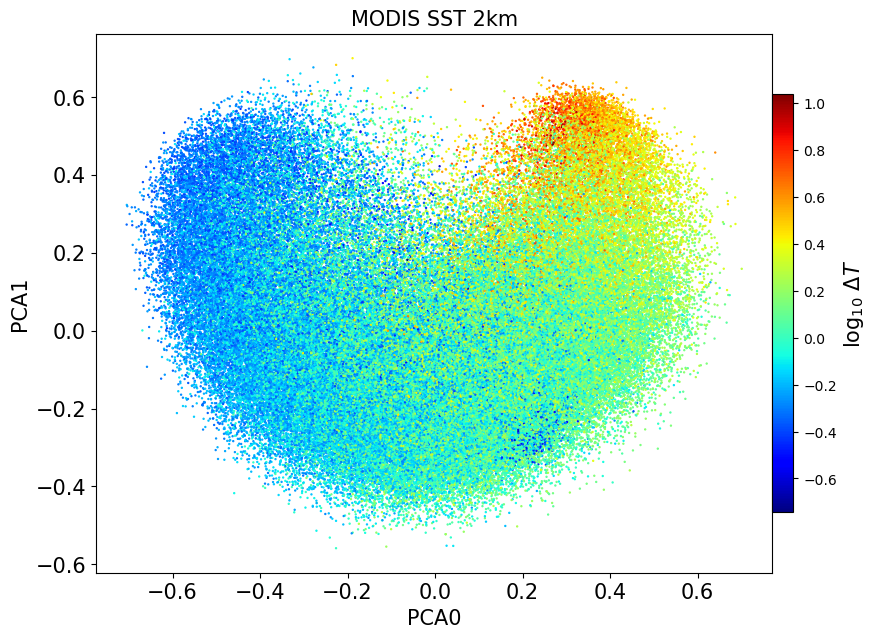

In [40]:
fig = plt.figure(figsize=(9,7))
ax = plt.gca()

scatter = ax.scatter(d['Y'][train_idx,0], d['Y'][train_idx,1], 
           c=np.log10(modis_train.DT), s=0.5, cmap='jet')
# Color bar
cbar = plt.colorbar(scatter, ax=ax, pad=0., fraction=0.030)
cbar.set_label(r'$\log_{10} \, \Delta T$', fontsize=15.)

# Label
ax.set_xlabel('PCA0')
ax.set_ylabel('PCA1')
ax.set_title('MODIS SST 2km')
rs_putils.set_fontsize(ax, 15.)
#
plt.savefig('PCA01_DT.png', dpi=300)
plt.show()